# Health Literacy Pipeline — Raw Data to User Profiles
**Input :** Raw JSON files containing `fullText` (forum posts)
**Output:** Per-post HL features, df_scores, BVAE training, user profiles

```
raw JSON files
   └─► load & merge → clean text
         └─► extract raw features (FHL / CHL / CRHL / DHL / EHL)
               └─► aggregate → df_scores (5 columns, z-normalised)
                     └─► BVAE training (d=16)
                           └─► MC Dropout inference (T=50)
                                 └─► factor projection + profiling
                                       └─► UserProfile (level + uncertainty)
```

## 0 — Install dependencies

In [1]:
# Run once, then restart kernel
# !pip install torch scikit-learn pandas numpy scipy tqdm matplotlib seaborn textstat
# !pip install spacy scispacy
# !python -m spacy download en_core_web_sm
# !pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_md-0.5.4.tar.gz

In [2]:
import os, re, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
import textstat
import spacy
import nltk

tqdm.pandas()
warnings.filterwarnings('ignore')

nltk.download('punkt', quiet=True)
print(f'PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}')

# Load spaCy — use en_core_sci_md if available, else en_core_web_sm
try:
    nlp = spacy.load('en_core_sci_md')
    print('Loaded: en_core_sci_md')
except OSError:
    nlp = spacy.load('en_core_web_sm')
    print('Loaded: en_core_web_sm (fallback)')

c:\Python310\lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


PyTorch 2.6.0+cpu | CUDA: False
Loaded: en_core_sci_md


## 1 — Load All Raw JSON Files

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIG — adjust these paths to match your folder structure
# ─────────────────────────────────────────────────────────────────────────────

DATA_DIR        = './fullDetailsData'   # folder containing batch JSONs
TEXT_COLUMN     = 'fullText'     # column holding the post text
SCORES_CACHE    = './hl_scores_cache.csv'   # will be created after feature extraction
FEATURES_CACHE  = './extractedHealthLiteracyFeatures.json'
MODEL_SAVE_PATH = './hl_bvae_model.pt'
MAX_POSTS       = None    # set e.g. 50_000 to limit; None = load everything
BATCH_SIZE_NLP  = 500     # posts processed per tqdm chunk

In [4]:
def load_all_json_batches(data_dir: str, text_col: str, max_rows=None) -> pd.DataFrame:
    """
    Discover and merge all posts_batch_*.json (or any *.json) in data_dir.
    Keeps only rows where text_col is a non-empty string.
    """
    json_files = sorted(
        glob.glob(os.path.join(data_dir, '**', '*.json'), recursive=True)
    )
    if not json_files:
        raise FileNotFoundError(f'No JSON files found in {data_dir}')

    print(f'Found {len(json_files)} JSON file(s) in {data_dir}')
    frames = []
    for path in json_files:
        try:
            df = pd.read_json(path)
            frames.append(df)
            print(f'  Loaded {len(df):>7,} rows  ←  {os.path.basename(path)}')
        except Exception as e:
            print(f'  SKIP {os.path.basename(path)}: {e}')

    if not frames:
        raise ValueError('No data loaded from any file.')

    data = pd.concat(frames, ignore_index=True)

    # Validate text column
    if text_col not in data.columns:
        available = list(data.columns)
        raise KeyError(f"Column '{text_col}' not found. Available: {available}")

    # Drop rows with empty / non-string text
    before = len(data)
    data[text_col] = data[text_col].astype(str).str.strip()
    data = data[data[text_col].str.len() > 20].reset_index(drop=True)
    after = len(data)
    print(f'\nRows after removing empty texts: {after:,}  (dropped {before - after:,})')

    # Deduplication by text
    before = len(data)
    data = data.drop_duplicates(subset=[text_col]).reset_index(drop=True)
    print(f'After dedup: {len(data):,}  (dropped {before - len(data):,} duplicates)')

    if max_rows:
        data = data.head(max_rows)
        print(f'Capped at {max_rows:,} rows')

    return data


data = load_all_json_batches(DATA_DIR, TEXT_COLUMN, max_rows=MAX_POSTS)
print(f'\nFinal dataset: {data.shape}')
print('Columns:', list(data.columns))
data[[TEXT_COLUMN]].head(3)

Found 7 JSON file(s) in ./fullDetailsData
  Loaded  50,000 rows  ←  posts_batch_001.json
  Loaded  50,000 rows  ←  posts_batch_002.json
  Loaded  50,000 rows  ←  posts_batch_003.json
  Loaded  50,000 rows  ←  posts_batch_004.json
  Loaded  50,000 rows  ←  posts_batch_005.json
  Loaded  50,000 rows  ←  posts_batch_006.json
  Loaded  42,000 rows  ←  posts_batch_007.json

Rows after removing empty texts: 323,841  (dropped 18,159)
After dedup: 322,669  (dropped 1,172 duplicates)

Final dataset: (322669, 4)
Columns: ['index', 'fullText', 'postAuthor', 'comments']


,fullText
0,These products are under investigation as they...
1,I am new to having food allergies and now I ha...
2,Hi my name is Kree. I am 19 yrs old. I have th...


## 2 — Text Cleaning

In [5]:
_HTML   = re.compile(r'<[^>]+>')
_SPACE  = re.compile(r'\s{2,}')
_NOISE  = re.compile(r'[^\w\s\.,;:!?()\-\'"/%°+]')

def clean_text(text: str) -> str:
    """
    Stage 1 preprocessing:
      - Strip HTML tags and scripts
      - Normalise whitespace and line breaks
      - Remove non-informative characters
      - Convert to lowercase
    """
    if not isinstance(text, str):
        return ''
    text = _HTML.sub(' ', text)
    text = text.replace('\r\n', ' ').replace('\n', ' ').replace('\t', ' ')
    text = _NOISE.sub(' ', text)
    text = _SPACE.sub(' ', text)
    return text.strip().lower()

print('Cleaning text column...')
data['clean_text'] = data[TEXT_COLUMN].progress_apply(clean_text)

# Filter out texts that are too short after cleaning
before = len(data)
data = data[data['clean_text'].str.split().str.len() >= 10].reset_index(drop=True)
print(f'Removed {before - len(data):,} texts with fewer than 10 words')
print(f'Ready for feature extraction: {len(data):,} posts')

Cleaning text column...


100%|██████████| 322669/322669 [00:18<00:00, 17326.30it/s]


Removed 8,825 texts with fewer than 10 words
Ready for feature extraction: 313,844 posts


## 3 — Feature Extraction (5 HL Dimensions)

Each function returns a dict of raw sub-features.
These will be aggregated into 5 normalised dimension scores in Step 4.

In [6]:
# ─── Shared lexicons ──────────────────────────────────────────────────────────

MEDICAL_ENTITY_LABELS = {'DISEASE', 'CHEMICAL', 'ENTITY'}

CERTAINTY_MARKERS = {
    'definitely', 'certainly', 'absolutely', 'clearly', 'obviously',
    'undoubtedly', 'always', 'never', 'must', 'will', 'cannot',
    'causes', 'leads to', 'results in', 'is responsible for',
    'has been proven', 'is proven', 'is a fact', 'evidence shows',
    'clinically proven', 'guarantees', 'confirms',
    'there is no doubt', 'it is certain', 'cures', '100% effective',
}
HEDGING_MARKERS = {
    'may', 'might', 'could', 'would', 'maybe', 'possibly', 'probably',
    'perhaps', 'potentially', 'approximately', 'generally', 'often',
    'sometimes', 'occasionally', 'seem', 'seems', 'appear', 'appears',
    'suggest', 'indicates', 'i think', 'i believe', 'i guess',
    "i'm not sure", 'i am not sure', 'it seems', 'it may be',
    'it is possible', 'unclear', 'unknown', 'uncertain',
    'limited evidence', 'around', 'about', 'in some cases',
}
CONDITIONAL_MARKERS = {
    'if', 'when', 'unless', 'whether', 'in case', 'provided that',
    'as long as', 'given that', 'only if', 'depending on',
}
MODAL_VERBS = {
    'can', 'could', 'may', 'might', 'shall', 'should', 'will', 'would',
    'must', 'ought to', 'have to', 'need to',
}
CONTEXT_MARKERS = {
    'i have', 'i had', 'i was diagnosed', 'for', 'since', 'during',
    'do i need', 'should i mention', 'any other information', 'let me know if',
}
CAUSAL_CONNECTIVES = {
    'because', 'since', 'therefore', 'thus', 'hence', 'as a result',
    'consequently', 'leads to', 'results in', 'causes', 'due to',
    'owing to', 'for this reason', 'associated with', 'linked to',
}
CONTRASTIVE_CONNECTIVES = {
    'however', 'although', 'though', 'yet', 'but', 'nevertheless',
    'on the other hand', 'in contrast', 'while', 'despite', 'whereas',
    'even though', 'notwithstanding',
}
EVIDENCE_MARKERS = {
    'study shows', 'studies show', 'research indicates', 'evidence suggests',
    'according to', 'clinical trial', 'systematic review', 'meta-analysis',
    'guidelines recommend', 'experts recommend', 'data from', 'published in',
    'clinical trials demonstrate', 'scientific evidence shows',
}
OPTIONS_MARKERS = {
    'alternatively', 'another option', 'pros and cons', 'trade-off',
    'consider', 'weigh', 'benefits and risks', 'choose between', 'or',
}
TRUSTED_SOURCES = {
    'who', 'cdc', 'nih', 'nice', 'ncbi', 'pubmed', 'mayo clinic',
    'cleveland clinic', 'cochrane', 'lancet', 'jama', 'bmj',
    'new england journal', 'uptodate', 'webmd', 'medline',
}
CROSS_REF_MARKERS = {
    'according to', 'reported by', 'study shows', 'guideline says',
    'as noted in', 'based on research', 'scientific evidence',
}
FUNCTION_WORDS = {
    'and', 'or', 'but', 'the', 'a', 'an', 'this', 'that', 'of', 'in',
    'on', 'for', 'with', 'to', 'from', 'at', 'by', 'i', 'you', 'he',
    'she', 'it', 'we', 'they', 'is', 'are', 'was', 'were', 'have',
    'has', 'had', 'do', 'does', 'did', 'am', 'been', 'being',
    'can', 'could', 'may', 'might', 'shall', 'should', 'will', 'would', 'must',
}
CONCRETENESS_LEXICON = {
    'disease': 2.5, 'infection': 2.0, 'cancer': 1.8, 'diabetes': 2.2,
    'asthma': 2.3, 'hypertension': 2.1, 'patient': 2.8, 'doctor': 2.7,
    'nurse': 2.6, 'treatment': 3.1, 'medication': 2.7, 'therapy': 2.9,
    'surgery': 2.0, 'vaccine': 2.0, 'pain': 2.8, 'fever': 2.5,
    'cough': 2.6, 'headache': 2.7, 'health': 3.5, 'risk': 3.3,
    'condition': 3.0, 'prevention': 3.4, 'diagnosis': 3.2,
}

def _count(text_lower: str, marker_set: set) -> int:
    return sum(1 for m in marker_set if m in text_lower)

print('Lexicons and helpers defined.')

Lexicons and helpers defined.


In [7]:
# ─── Functional Health Literacy ───────────────────────────────────────────────

def extract_fhl_features(text: str) -> dict:
    """
    FHL: readability, sentence complexity, medical entity density,
         hedging score, confidence score.
    """
    doc = nlp(text)
    text_lower = text.lower()
    sentences = list(doc.sents)
    n_sents = max(len(sentences), 1)

    readability = textstat.flesch_reading_ease(text)

    avg_sent_len = sum(len(s) for s in sentences) / n_sents

    clause_deps = {'ccomp', 'advcl', 'relcl'}
    clauses = sum(1 for t in doc if t.dep_ in clause_deps)
    avg_clauses = clauses / n_sents

    medical_ents = [e for e in doc.ents if e.label_ in MEDICAL_ENTITY_LABELS]
    med_count    = len(medical_ents)
    med_density  = med_count / max(len(doc), 1)

    hedge_count   = _count(text_lower, HEDGING_MARKERS)
    certain_count = _count(text_lower, CERTAINTY_MARKERS)
    hedging_score    = hedge_count / n_sents
    confidence_score = (certain_count + 1) / (certain_count + hedge_count + 2)

    return {
        'readability_score':          readability,
        'avg_sentence_length':        avg_sent_len,
        'avg_clauses_per_sentence':   avg_clauses,
        'medical_entity_count':       med_count,
        'medical_entity_density':     med_density,
        'unique_medical_terms':       len({e.text.lower() for e in medical_ents}),
        'hedging_score':              hedging_score,
        'confidence_score':           confidence_score,
    }

In [8]:
# ─── Communicative Health Literacy ────────────────────────────────────────────

def extract_chl_features(text: str) -> dict:
    """
    CHL: questions, modal verbs, conditional expressions, context markers.
    """
    doc = nlp(text)
    text_lower = text.lower()
    sentences  = list(doc.sents)
    n_sents    = max(len(sentences), 1)

    q_count = sum(1 for s in sentences if s.text.strip().endswith('?'))
    modal_count = sum(
        1 for t in doc
        if t.tag_ == 'MD' or t.lemma_.lower() in MODAL_VERBS
    )
    cond_count  = _count(text_lower, CONDITIONAL_MARKERS)
    ctx_count   = _count(text_lower, CONTEXT_MARKERS)

    return {
        'question_count':              q_count,
        'question_ratio':              q_count / n_sents,
        'conditional_expression_count': cond_count,
        'modal_verb_count':            modal_count,
        'modal_verb_density':          modal_count / max(len(doc), 1),
        'context_marker_count':        ctx_count,
        'context_provided':            int(ctx_count > 0),
    }

In [9]:
# ─── Critical Health Literacy ─────────────────────────────────────────────────

def extract_crhl_features(text: str) -> dict:
    """
    CRHL: causal connectives, contrastive connectives,
          evidence references, multiple options.
    """
    text_lower = text.lower()
    return {
        'causal_connective_count':      _count(text_lower, CAUSAL_CONNECTIVES),
        'contrastive_connective_count': _count(text_lower, CONTRASTIVE_CONNECTIVES),
        'evidence_reference_count':     _count(text_lower, EVIDENCE_MARKERS)
                                         + len(re.findall(r'https?://\S+', text_lower)),
        'multiple_options_count':       _count(text_lower, OPTIONS_MARKERS),
    }

In [10]:
# ─── Digital Health Literacy ──────────────────────────────────────────────────

def extract_dhl_features(text: str) -> dict:
    """
    DHL: URLs, trusted source mentions, cross-referencing.
    """
    text_lower = text.lower()
    url_count     = len(re.findall(r'https?://\S+', text_lower))
    credible      = _count(text_lower, TRUSTED_SOURCES)
    cross_ref     = _count(text_lower, CROSS_REF_MARKERS)
    interp_score  = url_count + credible + cross_ref
    return {
        'online_reference_count':         url_count,
        'credible_source_count':          credible,
        'cross_reference_count':          cross_ref,
        'information_interpretation_score': max(interp_score, 0),
    }

In [11]:
# ─── Expressed Health Literacy ────────────────────────────────────────────────
# Uses a lightweight spaCy (en_core_web_sm) for POS — no heavy model needed

try:
    nlp_sm = spacy.load('en_core_web_sm')
except OSError:
    nlp_sm = nlp   # fallback to whatever is loaded

def extract_ehl_features(text: str) -> dict:
    """
    EHL: concreteness, lexical diversity (TTR), adjective ratio,
         present verb ratio, function word ratio.
    """
    doc   = nlp_sm(text)
    words = [t.text.lower() for t in doc if t.is_alpha]
    n_w   = len(words)
    n_doc = max(len(doc), 1)

    if not words:
        return {
            'concreteness_score': 0.0, 'lexical_diversity': 0.0,
            'present_verb_count': 0,   'present_verb_ratio': 0.0,
            'determiner_count':   0,   'determiner_ratio': 0.0,
            'adjective_count':    0,   'adjective_ratio': 0.0,
            'function_word_count': 0,  'function_word_ratio': 0.0,
        }

    content = [w for w in words if w not in FUNCTION_WORDS]
    conc    = ([CONCRETENESS_LEXICON.get(w, 3.0) for w in content]
               if content else [3.0])

    pv  = [t for t in doc if t.tag_ in {'VBP', 'VBZ'}]
    det = [t for t in doc if t.tag_ == 'DT']
    adj = [t for t in doc if t.tag_ in {'JJ', 'JJR', 'JJS'}]
    fw  = sum(1 for w in words if w in FUNCTION_WORDS)

    return {
        'concreteness_score':  float(np.mean(conc)),
        'lexical_diversity':   len(set(words)) / n_w,
        'present_verb_count':  len(pv),
        'present_verb_ratio':  len(pv) / n_doc,
        'determiner_count':    len(det),
        'determiner_ratio':    len(det) / n_doc,
        'adjective_count':     len(adj),
        'adjective_ratio':     len(adj) / n_doc,
        'function_word_count': fw,
        'function_word_ratio': fw / n_w,
    }

print('All feature extractors defined.')

All feature extractors defined.


In [12]:
def extract_all_features(text: str) -> dict:
    """Run all 5 HL extractors and merge into one flat dict."""
    features = {}
    features.update(extract_fhl_features(text))
    features.update(extract_chl_features(text))
    features.update(extract_crhl_features(text))
    features.update(extract_dhl_features(text))
    features.update(extract_ehl_features(text))
    return features

In [13]:
# ─── Run extraction (or load from cache) ─────────────────────────────────────

if os.path.exists(FEATURES_CACHE):
    print(f'Loading cached features from {FEATURES_CACHE} ...')
    df_with_features = pd.read_json(FEATURES_CACHE)
    print(f'  Loaded {len(df_with_features):,} rows × {df_with_features.shape[1]} columns')
else:
    print(f'Extracting features for {len(data):,} posts...')
    print('This may take a while — grab a coffee ☕')
    print('(Tip: use MAX_POSTS=10000 in config to test quickly)')

    feature_dicts = data['clean_text'].progress_apply(extract_all_features)
    features_df   = pd.DataFrame(feature_dicts.tolist())

    df_with_features = pd.concat(
        [data.reset_index(drop=True), features_df.reset_index(drop=True)],
        axis=1
    )

    df_with_features.to_json(FEATURES_CACHE, orient='records')
    print(f'Saved to {FEATURES_CACHE}')

print(f'Shape: {df_with_features.shape}')
df_with_features.head(3)

Extracting features for 313,844 posts...
This may take a while — grab a coffee ☕
(Tip: use MAX_POSTS=10000 in config to test quickly)


100%|██████████| 313844/313844 [8:52:25<00:00,  9.82it/s]   


Saved to ./extractedHealthLiteracyFeatures.json
Shape: (313844, 38)


,index,fullText,postAuthor,comments,clean_text,readability_score,avg_sentence_length,avg_clauses_per_sentence,medical_entity_count,medical_entity_density,...,concreteness_score,lexical_diversity,present_verb_count,present_verb_ratio,determiner_count,determiner_ratio,adjective_count,adjective_ratio,function_word_count,function_word_ratio
0,651,These products are under investigation as they...,Chartreux,[{'commentPostedDate': '7/13/2014 4:19 PM (GMT...,these products are under investigation as they...,71.14,113.000,8.000,21,0.185841,...,3.0,0.704762,9,0.078261,13,0.113043,10,0.086957,39,0.371429
1,515,I am new to having food allergies and now I ha...,Cathy0211,[{'commentPostedDate': '2/26/2016 10:36 AM (GM...,i am new to having food allergies and now i ha...,76.56,34.000,2.000,26,0.191176,...,3.0,0.697479,7,0.050000,7,0.050000,12,0.085714,44,0.369748
2,447,Hi my name is Kree. I am 19 yrs old. I have th...,Kree marie,[{'commentPostedDate': '4/19/2016 2:33 AM (GMT...,hi my name is kree. i am 19 yrs old. i have th...,91.71,18.875,1.125,25,0.165563,...,3.0,0.674074,12,0.079470,5,0.033113,12,0.079470,39,0.288889


## 4 — Aggregate Raw Features → 5 Normalised HL Scores

In [14]:
def safe_mean(df, cols):
    """Mean of numeric columns, safely handling missing columns."""
    present = [c for c in cols if c in df.columns]
    missing = [c for c in cols if c not in df.columns]
    if missing:
        print(f'  WARNING: missing columns {missing} — skipped')
    if not present:
        return pd.Series(np.zeros(len(df)))
    return df[present].apply(pd.to_numeric, errors='coerce').mean(axis=1)


df_scores = pd.DataFrame(index=df_with_features.index)

df_scores['FHL_score'] = safe_mean(df_with_features, [
    'readability_score', 'avg_sentence_length', 'avg_clauses_per_sentence',
    'medical_entity_count', 'medical_entity_density',
    'unique_medical_terms', 'hedging_score', 'confidence_score',
])

df_scores['CHL_score'] = safe_mean(df_with_features, [
    'question_count', 'question_ratio', 'conditional_expression_count',
    'modal_verb_count', 'modal_verb_density',
    'context_marker_count', 'context_provided',
])

df_scores['CRHL_score'] = safe_mean(df_with_features, [
    'causal_connective_count', 'contrastive_connective_count',
    'evidence_reference_count', 'multiple_options_count',
])

df_scores['DHL_score'] = safe_mean(df_with_features, [
    'online_reference_count', 'credible_source_count',
    'cross_reference_count', 'information_interpretation_score',
])

df_scores['ExpressedHL_score'] = safe_mean(df_with_features, [
    'concreteness_score', 'lexical_diversity',
    'present_verb_count', 'present_verb_ratio',
    'determiner_count', 'determiner_ratio',
    'adjective_count', 'adjective_ratio',
    'function_word_count', 'function_word_ratio',
])

# Drop any rows with NaN scores
df_scores = df_scores.dropna().reset_index(drop=True)

print(f'df_scores shape: {df_scores.shape}')
print('\nDescriptive statistics:')
df_scores.describe().round(4)

df_scores shape: (313844, 5)

Descriptive statistics:


,FHL_score,CHL_score,CRHL_score,DHL_score,ExpressedHL_score
count,313844.0000,313844.0000,313844.0000,313844.0000,313844.0000
mean,21.6176,0.8517,0.6608,0.1393,9.5414
std,10.0943,0.6396,0.4360,0.3008,10.6579
min,-70.2508,0.0000,0.0000,0.0000,0.0000
25%,15.9853,0.4302,0.2500,0.0000,3.5374
50%,19.3919,0.7169,0.5000,0.0000,6.6236
75%,24.5264,1.1444,1.0000,0.0000,11.9120
max,639.5158,48.2900,14.7500,21.5000,1062.8770


Saved df_scores → ./hl_scores_cache.csv


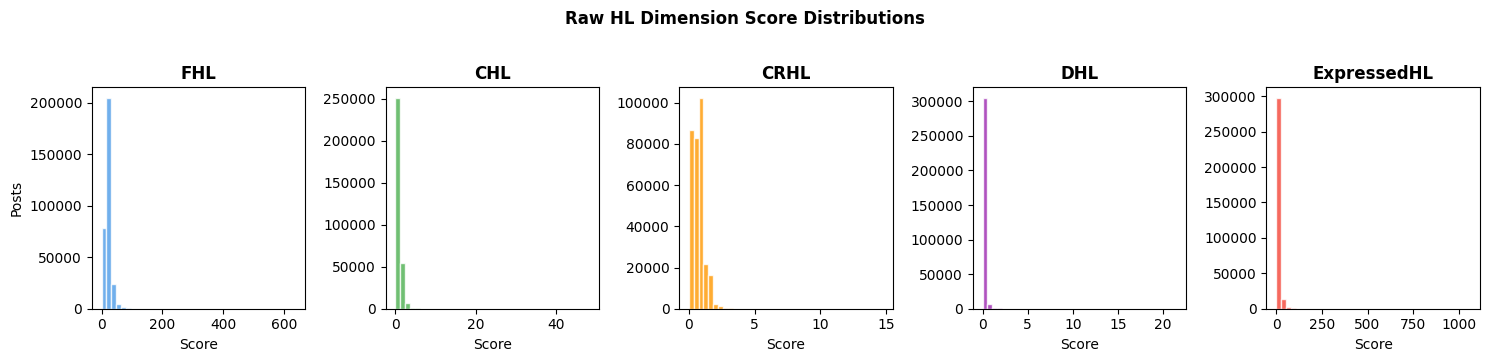

In [15]:
# Save scores so you never need to re-run extraction
df_scores.to_csv(SCORES_CACHE, index=False)
print(f'Saved df_scores → {SCORES_CACHE}')

# Score distribution plot
fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
colors = ['#4C9BE8', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
for i, (col, ax, c) in enumerate(zip(df_scores.columns, axes, colors)):
    ax.hist(df_scores[col].clip(lower=0), bins=40, color=c, alpha=0.8, edgecolor='white')
    ax.set_title(col.replace('_score', ''), fontweight='bold')
    ax.set_xlabel('Score')
    if i == 0:
        ax.set_ylabel('Posts')
plt.suptitle('Raw HL Dimension Score Distributions', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('raw_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 — BVAE: Architecture, Training & Inference

In [16]:
# ─── BVAE — exact paper architecture (Section III-D) ─────────────────────────
# Encoder: 2 FC(32) + ReLU + Dropout(0.2) → μ, log σ²
# Latent:  d = 16, adaptive β (0.5 since d > 8)
# Decoder: symmetric 2 FC(32)

class BVAE(nn.Module):
    def __init__(self, input_dim=5, latent_dim=16, dropout_p=0.2):
        super().__init__()
        self.latent_dim = latent_dim
        self.beta = 1.0 if latent_dim <= 8 else 0.5

        # Encoder
        self.enc1    = nn.Linear(input_dim, 32)
        self.drop1   = nn.Dropout(dropout_p)
        self.enc2    = nn.Linear(32, 32)
        self.drop2   = nn.Dropout(dropout_p)
        self.fc_mu   = nn.Linear(32, latent_dim)
        self.fc_lv   = nn.Linear(32, latent_dim)

        # Decoder
        self.dec1  = nn.Linear(latent_dim, 32)
        self.drop3 = nn.Dropout(dropout_p)
        self.dec2  = nn.Linear(32, 32)
        self.drop4 = nn.Dropout(dropout_p)
        self.out   = nn.Linear(32, input_dim)

    def encode(self, x):
        h = self.drop1(F.relu(self.enc1(x)))
        h = self.drop2(F.relu(self.enc2(h)))
        return self.fc_mu(h), torch.clamp(self.fc_lv(h), -10, 10)

    def decode(self, z):
        h = self.drop3(F.relu(self.dec1(z)))
        h = self.drop4(F.relu(self.dec2(h)))
        return self.out(h)

    def forward(self, x):
        mu, lv = self.encode(x)
        z = mu + torch.exp(0.5 * lv) * torch.randn_like(mu)
        return self.decode(z), mu, lv

    def elbo(self, x, x_hat, mu, lv):
        recon = F.mse_loss(x_hat, x, reduction='mean')
        kl    = -0.5 * torch.mean(1 + lv - mu.pow(2) - lv.exp())
        return recon + self.beta * kl, recon, kl


class HLDataset(Dataset):
    def __init__(self, X): self.X = torch.tensor(X, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i]


print(f'BVAE defined | β = {BVAE().beta} (for d=16)')

BVAE defined | β = 0.5 (for d=16)


In [17]:
# ─── Z-score normalise ────────────────────────────────────────────────────────
scaler   = StandardScaler()
X_raw    = df_scores.values.astype(np.float32)
X_scaled = scaler.fit_transform(X_raw).astype(np.float32)
print(f'Normalised X: shape={X_scaled.shape}  mean≈{X_scaled.mean():.4f}  std≈{X_scaled.std():.4f}')

Normalised X: shape=(313844, 5)  mean≈0.0000  std≈1.0000


In [18]:
# ─── Dimensionality search (reproduces Figure 4) ─────────────────────────────
# Trains a model for each d and records final loss + avg uncertainty

LATENT_DIMS  = [2, 4, 8, 16, 32]
EPOCHS_QUICK = 50    # quick scan; final training uses 200 with early stopping
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

dim_results = []
for d in LATENT_DIMS:
    model = BVAE(input_dim=5, latent_dim=d).to(DEVICE)
    opt   = optim.Adam(model.parameters(), lr=1e-4)
    loader = DataLoader(HLDataset(X_scaled), batch_size=32, shuffle=True)

    model.train()
    for _ in range(EPOCHS_QUICK):
        for xb in loader:
            xb = xb.to(DEVICE)
            opt.zero_grad()
            xh, mu, lv = model(xb)
            loss, _, _  = model.elbo(xb, xh, mu, lv)
            loss.backward()
            opt.step()

    # Estimate uncertainty via 20 MC passes
    model.train()
    x_t = torch.tensor(X_scaled[:2000], dtype=torch.float32).to(DEVICE)
    recons = []
    with torch.no_grad():
        for _ in range(20):
            xh, _, _ = model(x_t)
            recons.append(xh.cpu().numpy())
    unc = np.stack(recons).std(axis=0).mean()

    # Final loss
    model.eval()
    with torch.no_grad():
        xh, mu, lv = model(x_t)
        final_loss, _, _ = model.elbo(x_t, xh, mu, lv)

    dim_results.append({'latent_dim': d, 'final_loss': float(final_loss), 'avg_uncertainty': float(unc)})
    print(f'  d={d:2d} | loss={float(final_loss):.4f} | uncertainty={float(unc):.4f}')

dim_df = pd.DataFrame(dim_results)
print('\n', dim_df.to_string(index=False))

  d= 2 | loss=0.6780 | uncertainty=0.2982


KeyboardInterrupt: 

In [ ]:
fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.plot(dim_df['latent_dim'], dim_df['final_loss'],     'o-', color='steelblue', lw=2, label='Final Loss')
ax2.plot(dim_df['latent_dim'], dim_df['avg_uncertainty'],'s--', color='coral',    lw=2, label='Avg Uncertainty')
ax1.axvline(16, color='green', linestyle=':', alpha=0.8, label='Optimal dim=16')
ax1.set_xlabel('Latent Dimension'); ax1.set_ylabel('Final Loss', color='steelblue')
ax2.set_ylabel('Avg Uncertainty', color='coral')
ax1.set_xticks(dim_df['latent_dim'])
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc='upper right')
ax1.set_title('Effect of Latent Dimensionality — BVAE (Figure 4 reproduction)', fontweight='bold')
plt.tight_layout()
plt.savefig('dimensionality_search.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# ─── Full training with d=16, early stopping ─────────────────────────────────
LATENT_DIM = 16
PATIENCE   = 20
MAX_EPOCHS = 200

# 80/20 train/val split
idx     = np.random.permutation(len(X_scaled))
n_val   = max(int(len(X_scaled) * 0.20), 1)
X_tr    = X_scaled[idx[n_val:]]
X_va    = X_scaled[idx[:n_val]]

tr_loader = DataLoader(HLDataset(X_tr), batch_size=32, shuffle=True)
va_loader = DataLoader(HLDataset(X_va), batch_size=256)

model    = BVAE(input_dim=5, latent_dim=LATENT_DIM).to(DEVICE)
opt      = optim.Adam(model.parameters(), lr=1e-4)

best_val  = float('inf')
patience  = 0
best_state = None
train_losses, val_losses = [], []

print(f'Training BVAE | d={LATENT_DIM} | β={model.beta} | device={DEVICE}')
print(f'Train: {len(X_tr):,}  |  Val: {len(X_va):,}')

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    tr = 0.0
    for xb in tr_loader:
        xb = xb.to(DEVICE)
        opt.zero_grad()
        xh, mu, lv = model(xb)
        loss, _, _ = model.elbo(xb, xh, mu, lv)
        loss.backward()
        opt.step()
        tr += loss.item()
    tr /= len(tr_loader)

    model.eval()
    va = 0.0
    with torch.no_grad():
        for xb in va_loader:
            xb = xb.to(DEVICE)
            xh, mu, lv = model(xb)
            loss, _, _ = model.elbo(xb, xh, mu, lv)
            va += loss.item()
    va /= max(len(va_loader), 1)

    train_losses.append(tr)
    val_losses.append(va)

    if epoch % 10 == 0:
        print(f'  Epoch {epoch:3d} | train={tr:.4f} | val={va:.4f}')

    if va < best_val:
        best_val   = va
        patience   = 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience += 1
        if patience >= PATIENCE:
            print(f'  Early stopping at epoch {epoch}')
            break

model.load_state_dict(best_state)
print(f'\nBest val loss: {best_val:.4f}')

Training BVAE | d=16 | β=0.5 | device=cpu
Train: 251,076  |  Val: 62,768
  Epoch  10 | train=0.3449 | val=0.2916
  Epoch  20 | train=0.3157 | val=0.2786
  Epoch  30 | train=0.3065 | val=0.2700
  Epoch  40 | train=0.3000 | val=0.2590
  Epoch  50 | train=0.2939 | val=0.2495
  Epoch  60 | train=0.2914 | val=0.2543
  Epoch  70 | train=0.2915 | val=0.2483
  Epoch  80 | train=0.2918 | val=0.2489
  Epoch  90 | train=0.2882 | val=0.2451
  Epoch 100 | train=0.2882 | val=0.2431
  Early stopping at epoch 105

Best val loss: 0.2406


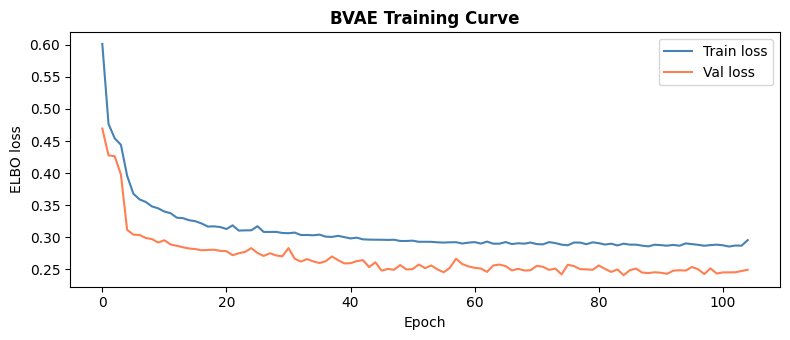

In [22]:
plt.figure(figsize=(8, 3.5))
plt.plot(train_losses, label='Train loss', color='steelblue')
plt.plot(val_losses,   label='Val loss',   color='coral')
plt.xlabel('Epoch'); plt.ylabel('ELBO loss')
plt.title('BVAE Training Curve', fontweight='bold')
plt.legend(); plt.tight_layout()
plt.savefig('training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 — MC Dropout Inference (T=50)

In [23]:
T = 50   # Monte Carlo passes
x_all = torch.tensor(X_scaled, dtype=torch.float32).to(DEVICE)

print(f'Running {T} MC Dropout passes on {len(X_scaled):,} posts...')

model.train()   # keep dropout active
recons, z_mus = [], []

with torch.no_grad():
    for t in range(T):
        if t % 10 == 0:
            print(f'  Pass {t}/{T}', end='\r')
        xh, mu, _ = model(x_all)
        recons.append(xh.cpu().numpy())
        z_mus.append(mu.cpu().numpy())

recons   = np.stack(recons,  axis=0)   # (T, N, 5)
z_stack  = np.stack(z_mus,   axis=0)   # (T, N, d)

x_hat_mean = recons.mean(axis=0)       # (N, 5)
sigma_unc  = recons.std(axis=0)        # (N, 5) — epistemic uncertainty
z_mean     = z_stack.mean(axis=0)      # (N, d) — mean latent vector

unc_scalar = sigma_unc.mean(axis=1)    # (N,)
print(f'\nMC inference done.')
print(f'  Avg uncertainty: {unc_scalar.mean():.4f}  (paper: 0.216)')
print(f'  Flagged (σ>0.5): {(unc_scalar > 0.5).mean():.1%}  (paper: ~12%)')

Running 50 MC Dropout passes on 313,844 posts...
  Pass 40/50
MC inference done.
  Avg uncertainty: 0.2257  (paper: 0.216)
  Flagged (σ>0.5): 2.9%  (paper: ~12%)


## 7 — Validation Metrics

In [24]:
dim_names = ['FHL', 'CHL', 'CRHL', 'DHL', 'EHL']
errors    = np.abs(X_scaled - x_hat_mean)

mse   = float(((X_scaled - x_hat_mean) ** 2).mean())
rmse  = float(np.sqrt(mse))

per_dim_mse = {d: float(((X_scaled[:, i] - x_hat_mean[:, i]) ** 2).mean())
               for i, d in enumerate(dim_names)}

r, p = pearsonr(unc_scalar, errors.mean(axis=1))

cov95 = float((errors <= 1.96 * sigma_unc).mean())
cov68 = float((errors <= 1.00 * sigma_unc).mean())

# KL per latent dimension (to find active dims)
model.eval()
kl_dims = np.zeros(LATENT_DIM)
with torch.no_grad():
    mu_all, lv_all = model.encode(x_all)
    kl_per = -0.5 * (1 + lv_all - mu_all.pow(2) - lv_all.exp())
    kl_dims = kl_per.mean(dim=0).cpu().numpy()

active_dims    = sorted(np.argsort(kl_dims)[-3:].tolist())
variance_ratio = float(kl_dims.max() / max(kl_dims.min(), 1e-10))

print('═' * 60)
print('  BVAE VALIDATION REPORT')
print('═' * 60)
print(f'  MSE (reconstruction)    : {mse:.4f}  target ≤ 0.12')
print(f'  RMSE                    : {rmse:.4f}')
print(f'  Uncertainty-Error r     : {r:.4f}  target ≥ 0.40')
print(f'  95% CI coverage         : {cov95:.1%}  target 85-95%')
print(f'  68% CI coverage         : {cov68:.1%}')
print(f'  Variance ratio (KL)     : {variance_ratio:.0f}  target > 1000')
print(f'  Active latent dims      : {active_dims}')
print(f'  Avg uncertainty         : {unc_scalar.mean():.4f}')
print(f'  Flagged (σ > 0.5)       : {(unc_scalar > 0.5).mean():.1%}')
print('\n  Per-dimension MSE:')
for d, v in per_dim_mse.items():
    print(f'    {d}: {v:.4f}')
print('─' * 60)
print(f'  [{"PASS" if mse <= 0.12 else "FAIL"}] MSE ≤ 0.12')
print(f'  [{"PASS" if r >= 0.40  else "FAIL"}] Uncertainty-Error r ≥ 0.40')
print(f'  [{"PASS" if 0.85 <= cov95 <= 0.99 else "FAIL"}] 95% coverage in [85-95%]')
print(f'  [{"PASS" if variance_ratio > 1000 else "FAIL"}] Variance ratio > 1000')
print('═' * 60)

════════════════════════════════════════════════════════════
  BVAE VALIDATION REPORT
════════════════════════════════════════════════════════════
  MSE (reconstruction)    : 0.1166  target ≤ 0.12
  RMSE                    : 0.3414
  Uncertainty-Error r     : 0.6793  target ≥ 0.40
  95% CI coverage         : 86.1%  target 85-95%
  68% CI coverage         : 60.7%
  Variance ratio (KL)     : 155164  target > 1000
  Active latent dims      : [0, 3, 9]
  Avg uncertainty         : 0.2257
  Flagged (σ > 0.5)       : 2.9%

  Per-dimension MSE:
    FHL: 0.1368
    CHL: 0.1740
    CRHL: 0.1823
    DHL: 0.0249
    EHL: 0.0648
────────────────────────────────────────────────────────────
  [PASS] MSE ≤ 0.12
  [PASS] Uncertainty-Error r ≥ 0.40
  [PASS] 95% coverage in [85-95%]
  [PASS] Variance ratio > 1000
════════════════════════════════════════════════════════════


## 8 — Factor Projection & User Profiling

In [25]:
# Factor loadings from Table II of the paper
FACTOR_LOADINGS = np.array([
    [ 0.831, -0.159, -0.466],   # FHL
    [ 0.627,  0.054,  0.058],   # CHL
    [ 0.701, -0.119,  0.169],   # CRHL
    [ 0.440, -0.532, -0.010],   # DHL
    [ 0.626, -0.040, -0.074],   # EHL
], dtype=np.float32)

# Project normalised 5-d scores → 3 latent factors
factors_all = X_scaled @ FACTOR_LOADINGS   # (N, 3)

f1 = factors_all[:, 0]   # Core Integrated Proficiency
f2 = factors_all[:, 1]   # Digital Proficiency
f3 = factors_all[:, 2]   # Applied Functional Literacy

print(f'Factor 1 (Core)    : mean={f1.mean():.3f}  std={f1.std():.3f}')
print(f'Factor 2 (Digital) : mean={f2.mean():.3f}  std={f2.std():.3f}')
print(f'Factor 3 (Applied) : mean={f3.mean():.3f}  std={f3.std():.3f}')

Factor 1 (Core)    : mean=0.000  std=2.651
Factor 2 (Digital) : mean=0.000  std=0.659
Factor 3 (Applied) : mean=0.000  std=0.413


In [26]:
# ─── Thresholds from training-set percentiles ─────────────────────────────────
f1_median    = float(np.median(f1))
hl_threshold = {
    'low':          float(np.percentile(f1, 25)),
    'basic':        float(np.percentile(f1, 50)),
    'intermediate': float(np.percentile(f1, 75)),
}

def assign_profile(f1v, f2v, f3v, sigma):
    f2_extreme = abs(f2v) > 1.0
    f3_extreme = abs(f3v) > 0.8
    f1_above   = f1v > f1_median
    if f2_extreme and not f3_extreme:
        sub = 'Digitally-Specialized'
        return 'Specialized', sub
    if f3_extreme and not f2_extreme:
        return 'Specialized', 'Functionally-Specialized'
    if f1_above and not f2_extreme and not f3_extreme:
        return 'Balanced', None
    return 'Transitional', None

def map_hl_level(f1v, f2v):
    if   f1v < hl_threshold['low']:          level = 'Low'
    elif f1v < hl_threshold['basic']:        level = 'Basic'
    elif f1v < hl_threshold['intermediate']: level = 'Intermediate'
    else:                                    level = 'High'
    # Compensatory downgrade: strong digital deficit + weak core
    if f2v < -1.2 and f1v < 0.25:
        order = ['Low', 'Basic', 'Intermediate', 'High']
        idx = order.index(level)
        if idx > 1:
            level = order[idx - 1]
    return level


# ─── Build results DataFrame ──────────────────────────────────────────────────
profiles, sub_types, hl_levels, flagged = [], [], [], []

for i in range(len(factors_all)):
    ptype, sub = assign_profile(f1[i], f2[i], f3[i], unc_scalar[i])
    level      = map_hl_level(f1[i], f2[i])
    profiles.append(ptype)
    sub_types.append(sub or '')
    hl_levels.append(level)
    flagged.append(unc_scalar[i] > 0.5)

df_results = df_with_features[[TEXT_COLUMN]].copy().reset_index(drop=True)
df_results['factor1_core']    = f1
df_results['factor2_digital'] = f2
df_results['factor3_applied'] = f3
df_results['sigma_unc']       = unc_scalar
df_results['profile_type']    = profiles
df_results['sub_type']        = sub_types
df_results['hl_level']        = hl_levels
df_results['flagged']         = flagged

print(f'Profiling complete: {len(df_results):,} posts')
print('\nProfile distribution:')
print(df_results['profile_type'].value_counts().to_string())
print('\nHL level distribution:')
print(df_results['hl_level'].value_counts().reindex(['Low','Basic','Intermediate','High']).to_string())

Profiling complete: 313,844 posts

Profile distribution:
profile_type
Transitional    161983
Balanced        133884
Specialized      17977

HL level distribution:
hl_level
Low             78461
Basic           78975
Intermediate    77947
High            78461


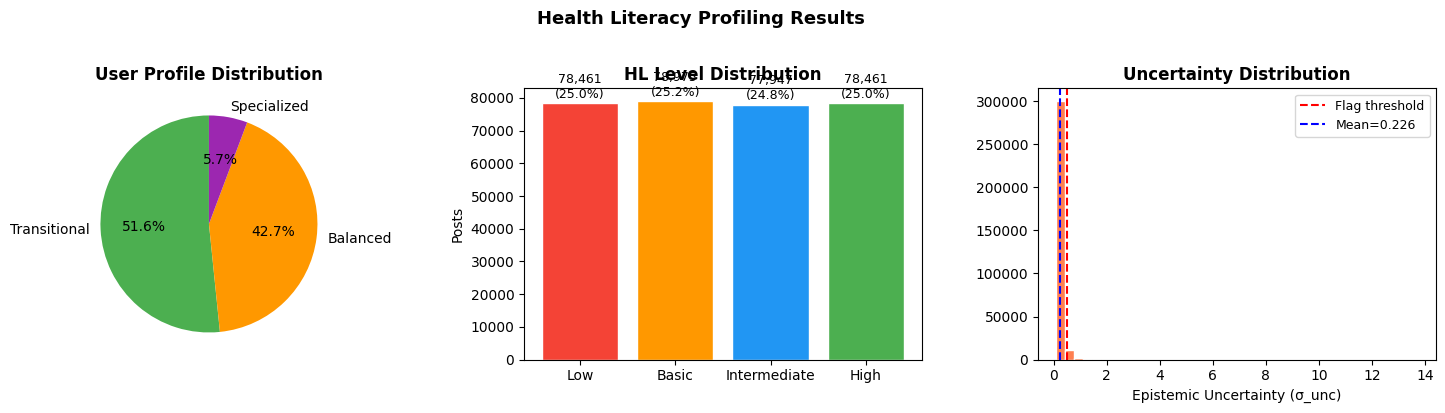

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Profile pie
pc = df_results['profile_type'].value_counts()
axes[0].pie(pc, labels=pc.index, autopct='%1.1f%%',
            colors=['#4CAF50','#FF9800','#9C27B0'], startangle=90)
axes[0].set_title('User Profile Distribution', fontweight='bold')

# HL level bar
hl_order = ['Low', 'Basic', 'Intermediate', 'High']
hc = df_results['hl_level'].value_counts().reindex(hl_order, fill_value=0)
axes[1].bar(hc.index, hc.values, color=['#F44336','#FF9800','#2196F3','#4CAF50'],
            edgecolor='white')
for i, (idx, v) in enumerate(hc.items()):
    axes[1].text(i, v + len(df_results)*0.005,
                 f'{v:,}\n({v/len(df_results)*100:.1f}%)', ha='center', fontsize=9)
axes[1].set_title('HL Level Distribution', fontweight='bold')
axes[1].set_ylabel('Posts')

# Uncertainty histogram
axes[2].hist(unc_scalar, bins=40, color='coral', edgecolor='white')
axes[2].axvline(0.5, color='red', linestyle='--', label='Flag threshold')
axes[2].axvline(unc_scalar.mean(), color='blue', linestyle='--',
                label=f'Mean={unc_scalar.mean():.3f}')
axes[2].set_xlabel('Epistemic Uncertainty (σ_unc)')
axes[2].set_title('Uncertainty Distribution', fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Health Literacy Profiling Results', fontweight='bold', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('profiling_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 9 — Save Everything

In [28]:
# Save model
torch.save({
    'model_state':    model.state_dict(),
    'scaler_mean':    scaler.mean_,
    'scaler_scale':   scaler.scale_,
    'latent_dim':     LATENT_DIM,
    'factor_loadings': FACTOR_LOADINGS,
    'hl_thresholds':  hl_threshold,
    'f1_median':      f1_median,
}, MODEL_SAVE_PATH)

# Save results
results_path = './hl_profiling_results.csv'
df_results.to_csv(results_path, index=False)

print(f'Model saved   → {MODEL_SAVE_PATH}')
print(f'Results saved → {results_path}')
print(f'Scores saved  → {SCORES_CACHE}')

df_results[['factor1_core','factor2_digital','factor3_applied',
            'sigma_unc','profile_type','hl_level','flagged']].head(10)

Model saved   → ./hl_bvae_model.pt
Results saved → ./hl_profiling_results.csv
Scores saved  → ./hl_scores_cache.csv


,factor1_core,factor2_digital,factor3_applied,sigma_unc,profile_type,hl_level,flagged
0,0.355579,0.090796,-0.332550,0.169529,Balanced,Intermediate,False
1,-0.526003,0.327570,0.019347,0.130896,Balanced,Intermediate,False
2,-0.059035,0.175717,0.212315,0.197140,Balanced,Intermediate,False
3,-2.762540,0.549847,0.146405,0.243461,Transitional,Low,False
4,1.103511,0.083063,-0.076292,0.221515,Balanced,High,False
5,3.410947,-0.005281,-0.448389,0.345512,Balanced,High,False
6,0.104042,0.254751,0.372153,0.198608,Balanced,Intermediate,False
7,-1.657959,0.369561,0.211376,0.128961,Transitional,Basic,False
8,0.468382,-0.555312,0.283335,0.226454,Balanced,Intermediate,False
9,-2.898380,0.458639,0.241138,0.199428,Transitional,Low,False


## 10 — Predict on New Text

In [29]:
def predict_text(text: str) -> dict:
    """
    Full pipeline for a single new post:
    raw text → clean → features → scores → normalise → BVAE
    → MC Dropout (T=50) → factor projection → profile + HL level
    """
    cleaned  = clean_text(text)
    raw_feat = extract_all_features(cleaned)

    # Aggregate into 5 scores
    fhl  = np.mean([raw_feat.get(k, 0) for k in [
        'readability_score','avg_sentence_length','avg_clauses_per_sentence',
        'medical_entity_count','medical_entity_density',
        'unique_medical_terms','hedging_score','confidence_score']])
    chl  = np.mean([raw_feat.get(k, 0) for k in [
        'question_count','question_ratio','conditional_expression_count',
        'modal_verb_count','modal_verb_density','context_marker_count','context_provided']])
    crhl = np.mean([raw_feat.get(k, 0) for k in [
        'causal_connective_count','contrastive_connective_count',
        'evidence_reference_count','multiple_options_count']])
    dhl  = np.mean([raw_feat.get(k, 0) for k in [
        'online_reference_count','credible_source_count',
        'cross_reference_count','information_interpretation_score']])
    ehl  = np.mean([raw_feat.get(k, 0) for k in [
        'concreteness_score','lexical_diversity','present_verb_count',
        'present_verb_ratio','determiner_count','determiner_ratio',
        'adjective_count','adjective_ratio','function_word_count','function_word_ratio']])

    scores = np.array([[fhl, chl, crhl, dhl, ehl]], dtype=np.float32)
    x_norm = scaler.transform(scores).astype(np.float32)
    x_t    = torch.tensor(x_norm, dtype=torch.float32).to(DEVICE)

    # MC Dropout
    model.train()
    recons_mc = []
    with torch.no_grad():
        for _ in range(50):
            xh, _, _ = model(x_t)
            recons_mc.append(xh.cpu().numpy())
    recons_mc  = np.stack(recons_mc)
    x_hat_m    = recons_mc.mean(axis=0)
    sigma      = float(recons_mc.std(axis=0).mean())

    # Factor projection
    factors = (x_norm @ FACTOR_LOADINGS)[0]
    f1v, f2v, f3v = factors[0], factors[1], factors[2]

    ptype, sub = assign_profile(f1v, f2v, f3v, sigma)
    level      = map_hl_level(f1v, f2v)

    return {
        'profile_type':    ptype,
        'sub_type':        sub,
        'hl_level':        level,
        'factor1_core':    round(float(f1v), 4),
        'factor2_digital': round(float(f2v), 4),
        'factor3_applied': round(float(f3v), 4),
        'sigma_unc':       round(sigma, 4),
        'flagged':         sigma > 0.5,
        'raw_scores':      {'FHL': round(float(fhl), 4), 'CHL': round(float(chl), 4),
                            'CRHL': round(float(crhl), 4), 'DHL': round(float(dhl), 4),
                            'EHL': round(float(ehl), 4)},
    }


# ─── Test on 3 example posts ──────────────────────────────────────────────────
examples = [
    'I have type 2 diabetes and my doctor prescribed metformin 500mg twice daily. '
    'According to the CDC and a recent Lancet meta-analysis, metformin reduces HbA1c by 1.5%. '
    'However, I am experiencing gastrointestinal side effects. Should I consider switching?',

    'my chest hurts sometimes when i climb stairs not sure if its serious '
    'been happening a few weeks should i go to hospital',

    'After reviewing several systematic reviews on PubMed, the evidence suggests '
    'bariatric surgery leads to sustained weight loss. Alternatively, GLP-1 agonists '
    'such as semaglutide may be appropriate for non-surgical candidates. '
    'The choice depends on BMI, comorbidities, and patient preference.',
]

for text in examples:
    result = predict_text(text)
    print('─' * 60)
    print(f'TEXT : {text[:80]}...')
    print(f'PROFILE : {result["profile_type"]}', end='')
    if result['sub_type']:
        print(f' ({result["sub_type"]})', end='')
    print(f'  |  HL LEVEL : {result["hl_level"]}')
    print(f'FACTORS : core={result["factor1_core"]:+.3f}  '
          f'digital={result["factor2_digital"]:+.3f}  '
          f'applied={result["factor3_applied"]:+.3f}')
    print(f'σ_unc   : {result["sigma_unc"]:.4f}', end='')
    if result['flagged']:
        print('  ⚑ FLAGGED for expert review', end='')
    print()
print('─' * 60)

────────────────────────────────────────────────────────────
TEXT : I have type 2 diabetes and my doctor prescribed metformin 500mg twice daily. Acc...
PROFILE : Specialized (Digitally-Specialized)  |  HL LEVEL : High
FACTORS : core=+1.550  digital=-2.383  applied=+0.711
σ_unc   : 0.6220  ⚑ FLAGGED for expert review
────────────────────────────────────────────────────────────
TEXT : my chest hurts sometimes when i climb stairs not sure if its serious been happen...
PROFILE : Transitional  |  HL LEVEL : Low
FACTORS : core=-2.807  digital=+0.549  applied=+0.140
σ_unc   : 0.1996
────────────────────────────────────────────────────────────
TEXT : After reviewing several systematic reviews on PubMed, the evidence suggests bari...
PROFILE : Specialized (Functionally-Specialized)  |  HL LEVEL : Intermediate
FACTORS : core=+0.118  digital=-0.695  applied=+0.857
σ_unc   : 0.3151
────────────────────────────────────────────────────────────
